<a href="https://colab.research.google.com/github/Yuyang-Yao/Math_-5750_Project2/blob/main/Math5750_project2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Math 5750/6880: Mathematics of Data Science \\
Project 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, RANSACRegressor, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor

import seaborn as sns

# imports and setup

from sklearn.metrics import confusion_matrix # for Q1 classification like mission


from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn import tree, svm, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, KFold
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords

import re

https://scikit-learn.org/stable/modules/generated/sklearn.random_projection.GaussianRandomProjection.html


An example of how pairwise_distances work with np.corrcoef

In [ ]:

import numpy as np
from sklearn.metrics import pairwise_distances # for computing pairwise distance
import matplotlib.pyplot as plt

X = np.array([0,2,4,6]).reshape(-1,1)
X_r = np.array([1,3,5,7]).reshape(-1,1)

D_original1 = pairwise_distances(X)
D_reduced1  = pairwise_distances(X_r)

print(X)
print(D_original1)
print(D_original1.ravel())

print(np.corrcoef(D_original1.ravel(), D_reduced1.ravel())[0,1])


[[0]
 [2]
 [4]
 [6]]
[[0. 2. 4. 6.]
 [2. 0. 2. 4.]
 [4. 2. 0. 2.]
 [6. 4. 2. 0.]]
[0. 2. 4. 6. 2. 0. 2. 4. 4. 2. 0. 2. 6. 4. 2. 0.]
1.0


X – 4×1 column vector: four samples [0],[2],[4],[6].

D_original1 – 4×4 symmetric matrix of pairwise Euclidean distances between points (|xi−xj|).

D_original1.ravel() – flattens the distance matrix row-wise into a 1D array of 16 elements.

np.corrcoef(...) = 1.0 – perfect correlation; both distance matrices preserve proportional distances exactly.

When correlation ≈ 1, pairwise distances in projected space vary proportionally to those in original space—meaning scaling, not structure, changed. It works because linear transformations preserve relative spacing; high correlation implies geometric relationships (angles, magnitudes) are consistently maintained across all point pairs.

Sample shape: (1000, 784)


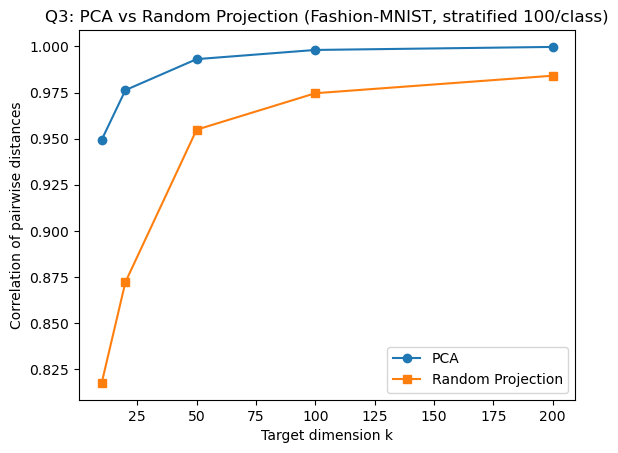

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import pairwise_distances # for computing pairwise distance
import matplotlib.pyplot as plt

# Step 1 load data and scale X
X_3, y_3 = fetch_openml("Fashion-MNIST", version=1, as_frame=False, return_X_y=True, parser="auto")
y_3 = y_3.astype(int)# an arry of true class int
X_3_scaled = StandardScaler().fit_transform(X_3)
labels_Q3=np.unique(y_3)

#Step 2Stratified sampling: 1000 per class

sample_index_3 = []
for i in labels_Q3:
    index_class_i = np.where(y_3 == i)[0] # all index for class i
    chosen_index = np.random.choice(index_class_i, 100, replace=False)# radnomly pick 100
    sample_index_3.extend(chosen_index)

X_sample_3 = X_3_scaled[sample_index_3]
y_sample_3 = y_3[sample_index_3]

print("Sample shape:", X_sample_3.shape)


# Step 3.1: Define the correlation function for the " correlation between pairwise distances in the original standardized space and the reduced space."

def correlation_distances(X, X_reduced):
    D_origianl = pairwise_distances(X, n_jobs=-1) #n_jobs=-1?
    D_reduced  = pairwise_distances(X_reduced, n_jobs=-1)
    return np.corrcoef(D_origianl.ravel(), D_reduced.ravel())[0,1]
    # This computes the correlation between all pairwise distances in the original space
    # and the corresponding pairwise distances in the reduced (projected) space — exactly what J–L lemma describes.

#step 3.2 compute correlation for diff dim k
k_values = [10, 20, 50, 100, 200]
corr_pca, corr_rp = [], []

for k in k_values:
    # PCA
    pca = PCA(n_components=k, random_state=42)
    X_pca = pca.fit_transform(X_sample_3)
    corr_pca.append(correlation_distances(X_sample_3, X_pca))

    # Random Projection
    rp = GaussianRandomProjection(n_components=k, random_state=42)
    X_rp = rp.fit_transform(X_sample_3)
    corr_rp.append(correlation_distances(X_sample_3, X_rp))


# Step 4: Plot

plt.plot(k_values, corr_pca, marker='o', label="PCA")
plt.plot(k_values, corr_rp, marker='s', label="Random Projection")
plt.xlabel("Target dimension k")
plt.ylabel("Correlation of pairwise distances")
plt.title("Q3: PCA vs Random Projection (Fashion-MNIST, stratified 100/class)")
plt.legend()
plt.show()


In [ ]:
corr_pca

[0.934305902574857,
 0.9683598695175379,
 0.9896120028397017,
 0.9972682883671433,
 0.9996531535957175]

in loops for average

In [ ]:
#iniialization

corr_pca_avg_dic_sum=dict.fromkeys(k_values, 0)
corr_rp_avg_dic_sum=dict.fromkeys(k_values, 0)
print(corr_rp_avg_dic_sum)

{10: 0, 20: 0, 50: 0, 100: 0, 200: 0}


Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
10 12.129794043102223
20 13.243868366934457
50 14.316144635073002
100 14.645198027926817
200 14.77518208593272
[14.028438931292968, 14.563889272637061, 14.871604506440612, 14.96515833843616, 14.995452775812213]


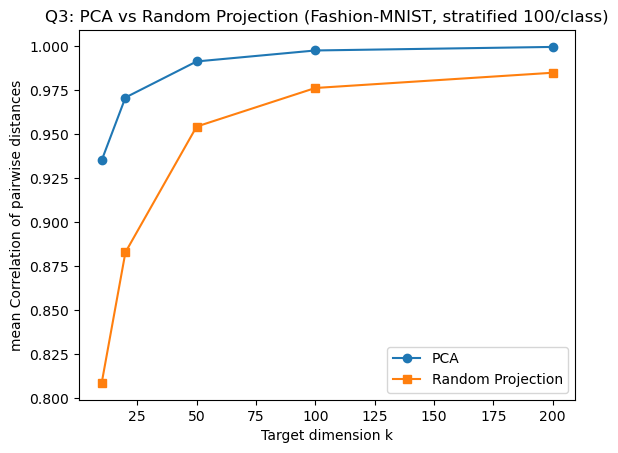

In [ ]:
#Step 2Stratified sampling: 1000 per class
for i in range (0,15):
    sample_index_4 = []
    for i_2 in labels_Q3:
        index_class_i_2 = np.where(y_3 == i_2)[0] # all index for class i
        chosen_index_2 = np.random.choice(index_class_i_2, 100, replace=False)# radnomly pick 100
        sample_index_4.extend(chosen_index_2)

    X_sample_3_2 = X_3_scaled[sample_index_4]
    y_sample_3_2 = y_3[sample_index_4]

    print("Sample shape:", X_sample_3_2.shape)# track for possible debug


    #step 3.2 compute correlation for diff dim k

    for k in k_values:
    # PCA
        pca_2 = PCA(n_components=k, random_state=k)
        X_pca_2 = pca_2.fit_transform(X_sample_3_2)
        corr_coef_k_pca=correlation_distances(X_sample_3_2, X_pca_2)
        corr_pca_avg_dic_sum[k]+=corr_coef_k_pca

    # Random Projection
        rp_2 = GaussianRandomProjection(n_components=k, random_state=42)
        X_rp_2 = rp_2.fit_transform(X_sample_3_2)
        corr_coef_k_rp=correlation_distances(X_sample_3_2, X_rp_2)
        corr_rp_avg_dic_sum[k]+=corr_coef_k_rp

# take values from key to be a list to compute mean corr coef for pairwise dist
for key, value in corr_rp_avg_dic_sum.items():
    print(key, value)


corr_pca_avg_l_sum= list(corr_pca_avg_dic_sum.values())
print(corr_pca_avg_l_sum)
corr_pca_avg=[j/15 for j in corr_pca_avg_l_sum ]

corr_rp_avg_l_sum= list(corr_rp_avg_dic_sum.values())
corr_rp_avg=[m/15 for m in corr_rp_avg_l_sum]

# ------------------------
# Plot
# ------------------------
plt.plot(k_values, corr_pca_avg, marker='o', label="PCA")
plt.plot(k_values, corr_rp_avg, marker='s', label="Random Projection")
plt.xlabel("Target dimension k")
plt.ylabel("mean Correlation of pairwise distances")
plt.title("Q3: PCA vs Random Projection (Fashion-MNIST, stratified 100/class)")
plt.legend()
plt.show()

# Q4
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

In [ ]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_samples, silhouette_score

In [ ]:
# step 1 choose index for stratification
class_labels=np.unique(y_3)
sample_index_Q4 = []
for k in class_labels:
    index_k = np.where(y_3 == k)[0]
    chosen_index_Q4 = np.random.choice(index_k, 200, replace=False)
    sample_index_Q4.extend(chosen_index_Q4)  # extend([3,4]) → [3,4]; but append([1,2]) → [[3,4]]]

X_sample_Q4 = X_3_scaled[sample_index_Q4]
y_sample_Q4 = y_3[sample_index_Q4]

print("Sample shape:", X_sample_Q4.shape)

Sample shape: (2000, 784)


In [ ]:
Spectral_clustering_KNN = SpectralClustering( # Gausian kernel method for constructing the graph Laplacian
    n_clusters=10,
    affinity="nearest_neighbors",   # uses kNN internally
    n_neighbors=10,           # number of neighbors in kNN grap
    n_components=11,  # use same reduced dim as Q2
    assign_labels="kmeans",
    random_state=42)


In [ ]:
labels_spec_clustering_obj = Spectral_clustering_KNN .fit(X_sample_Q4)
labels_spec_clustering_KNN=Spectral_clustering_KNN.labels_
print(labels_spec_clustering_KNN)

[8 8 1 ... 7 7 2]


In [ ]:
#SSE_Q2_s = Spectral_clustering.inertia_
#print("inertia value or SSE:", SSE_Q2_s)

silhouette_score_Q4_spectral_KNN = silhouette_score(X_sample_Q4, labels_spec_clustering_KNN )
print("silhouette_score for Q4 is knn:", silhouette_score_Q4_spectral_KNN )


silhouette_score for Q4 is knn: 0.11914852625273956


In [ ]:
homogeneity_completeness_v_measure_Q4_sample_KNN=metrics.homogeneity_completeness_v_measure(y_sample_Q4,labels_spec_clustering_KNN)
print('homogeneity_completeness_v_measure score',homogeneity_completeness_v_measure_Q4_sample_KNN) # Evaluating cluster quality with known ground-truth labels

homogeneity_completeness_v_measure score (0.5641606394499068, 0.6050978070875916, 0.5839125931263036)


Spectral clustering constructs a Laplacian graph that captures nonlinear manifold structures,
so even if geometric distances overlap ( silhouette_score is lower), clustering can better match actual classes.

In [ ]:
import pyamg
Spectral_clustering_rbf = SpectralClustering( # Gausian kernel method for constructing the graph Laplacian
    n_clusters=10,
    affinity="rbf",   # uses kNN internally
    gamma=0.00015,    # bandwith for the Guassian kernel
    eigen_solver="arpack",
    n_components=10, # use same reduced dim as Q2
    assign_labels="kmeans",
    random_state=42)

labels_spec_clustering_rbf = Spectral_clustering_rbf .fit_predict(X_sample_Q4)
labels_spec_clustering_rbf

array([2, 2, 7, ..., 1, 1, 3])

$$
\text{With RBF affinity } (A_{ij} = e^{-\gamma \lVert x_i - x_j \rVert^2}).
$$

$$
\text{As } \gamma \to \infty, \; A \to I \; (\text{off-diagonals } \to 0). $$ $$\gamma = \frac{1}{2\sigma^2}$$. Where sigma is the bandwidth.

So this is like: When bandwidth is small, the weight matrix W will only give weights and edges to close neighbors. So this will separate "some groups of Friends" out of the main network. Or evenly, it will separate data points (as nodes) into many small sub-networks only. Therefore, the graphs are disconnected when the bandwidth is very small (Python returns error). But recall the bias is slight when the bandwidth is small.
This is similar when you perform a PageRank analysis using MC. You will want to add some weak links (small weights to edges) to the disconnected nodes (i.e., ensure that MC is somewhat positive for every entry).


Big bandwidth, low variance, but high bias; its prediction results are inferior to those of constructing L using KNN.
But it adds a connection to almost every mutual node.


In [ ]:
silhouette_score_Q4_spectral_rbf = silhouette_score(X_sample_Q4, labels_spec_clustering_rbf)
print("silhouette_score for Q4 rbf is:", silhouette_score_Q4_spectral_rbf )

silhouette_score for Q4 rbf is: 0.13136344262430222


In [ ]:
homogeneity_completeness_v_measure_Q4_sample_rbf=metrics.homogeneity_completeness_v_measure(y_sample_Q4,labels_spec_clustering_rbf)
print('homogeneity_completeness_v_measure score',homogeneity_completeness_v_measure_Q4_sample_rbf)

homogeneity_completeness_v_measure score (0.5178735532874522, 0.5522055114839538, 0.5344887864677562)


KNN did better than rbf kernel for graph laplacian. So only report confusion matrix for the one using k-nearest neighbor
as graph laplacian L.

https://scikit-learn.org/stable/auto_examples/cluster/plot_adjusted_for_chance_measures.html
https://www.geeksforgeeks.org/dsa/hungarian-algorithm-assignment-problem-set-1-introduction/
4.3 confusion matrix
confusion matrix follows true labels (0–9) in rows for the confusion_matrix_aligned

$\verb|(i%3==0)| $

In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def hungarian_confusion_matrix(y_true, y_pred_clustering):
    # biuld initial confusion matrix
    original_confusion_matrix = confusion_matrix(y_true, y_pred_clustering)

    # Use Hungarian algorithm to find optimal column permutation
    row_index, col_index = linear_sum_assignment(-original_confusion_matrix )
    # row_ind and col_ind are index arrays showing the optimal one-to-one assignment between true classes (rows) and predicted clusters (columns)
    #that achieves the maximum overall matching.

    # Reorder columns (predicted labels) to best match true classes
    confusion_matrix_aligned = original_confusion_matrix[:, col_index ]
    return  confusion_matrix_aligned, row_index, col_index



In [ ]:
confusion_matrix_aligned_Q4, row_index, col_index = hungarian_confusion_matrix(y_sample_Q4, labels_spec_clustering_rbf)
print("Aligned Confusion Matrix:\n", confusion_matrix_aligned_Q4)
print( 're-ordered predicted labels is',col_index)

Aligned Confusion Matrix:
 [[125   8   3   0   1  58   3   0   2   0]
 [  5 187   1   0   0   7   0   0   0   0]
 [  3   1  75   0  70  47   0   1   3   0]
 [ 15 125   0   0  12  47   0   0   1   0]
 [  0   5  30   0 139  24   0   0   2   0]
 [  0   0   0   9   0 131   0  46   0  14]
 [ 42   6  24   0  51  72   3   0   1   1]
 [  0   0   0   0   0  16   0 157   0  27]
 [  2   0   1   0   0  22  67   5  99   4]
 [  0   0   0  72   0   3   0   7   0 118]]
re-ordered predicted labels is [2 7 9 3 0 8 6 4 5 1]


In [ ]:
import numpy as np

# From confusion_matrix_aligned (rows = true, col_index = predicted after Hungarian)
TP = np.diag(confusion_matrix_aligned_Q4)
precision = TP / confusion_matrix_aligned_Q4.sum(axis=0)      # per-class precision
recall = TP  / confusion_matrix_aligned_Q4.sum(axis=1)         # per-class recall
accuracy= TP .sum() / confusion_matrix_aligned_Q4.sum()  # overall accuracy
f1_accuracy = 2 * np.mean(precision) * np.mean(recall) / (np.mean(precision) + np.mean(recall))  # f1 accuracy



print("Precision:", np.mean(precision))
print("Recall:", np.mean(recall))
print("Accuracy:", accuracy)
print("f1 Accuracy:", f1_accuracy)
print(TP)

Precision: 0.49940718535477624
Recall: 0.5170000000000001
Accuracy: 0.517
f1 Accuracy: 0.5080513371976942
[125 187  75   0 139 131   3 157  99 118]


In [ ]:
# knn

In [ ]:
confusion_matrix_aligned_Q4_knn, row_index_knn, col_index_knn = hungarian_confusion_matrix(y_sample_Q4, labels_spec_clustering_KNN )
print("Aligned Confusion Matrix:\n", confusion_matrix_aligned_Q4_knn)
print( 're-ordered predicted labels is',col_index_knn)

Aligned Confusion Matrix:
 [[120   0   5  23   0  50   0   0   2   0]
 [  0 183   2  10   0   5   0   0   0   0]
 [  0   0 151   2   0  47   0   0   0   0]
 [  7   1   0 159   0  33   0   0   0   0]
 [  0   0 133  41   0  26   0   0   0   0]
 [  0   0   0   0   1 158   0  30   0  11]
 [ 41   0  67  21   0  70   1   0   0   0]
 [  0   0   0   0   0  17   0 146   0  37]
 [  2   0   7   2   0  24  70   2  86   7]
 [  0   0   0   0  87   8   0   3   0 102]]
re-ordered predicted labels is [8 4 0 1 9 2 5 3 6 7]


In [ ]:
# From confusion_matrix_aligned (rows = true, col_index = predicted after Hungarian)
TP_knn = np.diag(confusion_matrix_aligned_Q4_knn)
precision_knn = TP_knn / confusion_matrix_aligned_Q4_knn.sum(axis=0)      # per-class precision
recall_knn = TP_knn  / confusion_matrix_aligned_Q4_knn.sum(axis=1)         # per-class recall
accuracy_knn = TP_knn .sum() / confusion_matrix_aligned_Q4_knn.sum()     # overall accuracy

f1_accuracy_knn = 2 * np.mean(precision_knn) * np.mean(recall_knn) / (np.mean(precision_knn) + np.mean(recall_knn))

print("Precision:", np.mean(precision_knn))
print("Recall:", np.mean(recall_knn))
print("Accuracy:", accuracy_knn)
print("f1 Accuracy knn:", f1_accuracy_knn)
print(TP_knn)

Precision: 0.553882446107576
Recall: 0.5529999999999999
Accuracy: 0.553
f1 Accuracy knn: 0.5534408712950554
[120 183 151 159   0 158   1 146  86 102]


V-measure (choose t-SNE/UMAP based on structure):
Use when you want to evaluate how well clusters reflect true class relationships overall—use entropy rather than only the relative frequency of accuracy.

Accuracy (choose by label alignment):
Use when you need to measure how precisely each cluster corresponds to one true class—good for assessing classification-like performance after Hungarian label alignment.